In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('Algerian_forest_fires_dataset_CLEANED.csv')

# View the first 5 rows to ensure it loaded correctly
display(df.head())

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [3]:
# Check data types and look for null (missing) values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    str    
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), str(1)
memory usage: 28.6 KB


In [4]:
# Print all unique values in the Classes column
print("Unique target values:", df['Classes'].unique())

Unique target values: <StringArray>
[  'not fire   ',       'fire   ',          'fire',         'fire ',
      'not fire',     'not fire ', 'not fire     ',  'not fire    ']
Length: 8, dtype: str


In [5]:
# 1. Strip extra spaces from the column names (just to be safe!)
df.columns = df.columns.str.strip()

# 2. Strip extra spaces from the values inside the 'Classes' column
df['Classes'] = df['Classes'].str.strip()

# 3. Convert the text into binary numbers (1 for fire, 0 for not fire)
df['Classes'] = df['Classes'].map({'fire': 1, 'not fire': 0})

# 4. Verify the fix by counting the total number of each class
print(df['Classes'].value_counts())

Classes
1    137
0    106
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Isolate features (X) and target (y)
# We drop dates and Region to force the model to learn pure weather/environmental physics
X = df.drop(['day', 'month', 'year', 'Region', 'Classes'], axis=1)
y = df['Classes']

# 2. Split the dataset: 80% for training, 20% for testing our model's accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Standardize the data (Scale so mean=0 and variance=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Note: We only transform the test set to prevent data leakage

print("Training features shape:", X_train_scaled.shape)
print("Testing features shape:", X_test_scaled.shape)

Training features shape: (194, 10)
Testing features shape: (49, 10)


In [7]:
import torch
import torch.nn as nn

# 1. Hardware Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Compute device configured to: {device}")

# 2. Convert scaled Numpy arrays into PyTorch tensors and send them to the device
# We use float32 because Neural Networks expect 32-bit floating point numbers
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
# We reshape y to be a column vector using .view(-1, 1) so it aligns with the network's output
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1).to(device)

print("X_train tensor shape:", X_train_tensor.shape)
print("y_train tensor shape:", y_train_tensor.shape)

Compute device configured to: cuda
X_train tensor shape: torch.Size([194, 10])
y_train tensor shape: torch.Size([194, 1])


In [8]:
class WildfirePredictor(nn.Module):
    def __init__(self, input_size):
        super(WildfirePredictor, self).__init__()
        
        # Layer 1: 10 inputs -> 16 hidden nodes
        self.layer1 = nn.Linear(input_size, 16)
        self.relu1 = nn.ReLU() # Activation function to learn non-linear patterns
        
        # Layer 2: 16 hidden nodes -> 8 hidden nodes
        self.layer2 = nn.Linear(16, 8)
        self.relu2 = nn.ReLU()
        
        # Output Layer: 8 hidden nodes -> 1 output prediction
        self.output_layer = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid() # Squashes output to a probability between 0 and 1

    def forward(self, x):
        # This defines how data flows forward through the network
        x = self.layer1(x)
        x = self.relu1(x)
        
        x = self.layer2(x)
        x = self.relu2(x)
        
        x = self.output_layer(x)
        x = self.sigmoid(x)
        return x

# Instantiate the model
input_dimensions = X_train_tensor.shape[1] # This is 10
model = WildfirePredictor(input_dimensions).to(device) # Send model to the GPU

print("Neural Network Architecture successfully initialized:")
print(model)

Neural Network Architecture successfully initialized:
WildfirePredictor(
  (layer1): Linear(in_features=10, out_features=16, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (relu2): ReLU()
  (output_layer): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [9]:
import torch.optim as optim

# 1. Define Loss Function and Optimizer
criterion = nn.BCELoss() # Binary Cross Entropy Loss for 0 vs 1
optimizer = optim.Adam(model.parameters(), lr=0.01) # lr is the learning rate (how big of a step it takes when adjusting)

# 2. Set the number of epochs (how many times it sees the whole dataset)
epochs = 150 

print("Starting Training...\n")

for epoch in range(epochs):
    # Set model to training mode
    model.train()
    
    # Forward pass: Pass the data through the network to get predictions
    predictions = model(X_train_tensor)
    
    # Calculate the Loss: Compare predictions to actual answers
    loss = criterion(predictions, y_train_tensor)
    
    # Backward pass: Clear old gradients, calculate new ones, and update weights
    optimizer.zero_grad() # Clear memory from the last step
    loss.backward()       # Calculate the math adjustments
    optimizer.step()      # Apply the adjustments to the network
    
    # Print the progress every 25 epochs
    if (epoch + 1) % 25 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

print("\nTraining Complete!")

Starting Training...

Epoch [25/150], Loss: 0.1911
Epoch [50/150], Loss: 0.0560
Epoch [75/150], Loss: 0.0209
Epoch [100/150], Loss: 0.0089
Epoch [125/150], Loss: 0.0044
Epoch [150/150], Loss: 0.0026

Training Complete!


In [10]:
# 1. Put the model in evaluation mode (disables training-specific layers like dropout)
model.eval()

# 2. Turn off gradient calculation to save memory and speed up testing
with torch.no_grad():
    # Pass the unseen test data through the model
    test_predictions = model(X_test_tensor)
    
    # Round the probabilities (e.g., 0.85 becomes 1.0, 0.20 becomes 0.0)
    rounded_predictions = test_predictions.round()
    
    # Calculate how many it got right
    correct_guesses = (rounded_predictions == y_test_tensor).sum().item()
    total_samples = y_test_tensor.size(0)
    
    accuracy = (correct_guesses / total_samples) * 100
    print(f"Test Set Accuracy: {accuracy:.2f}%\n")
    
    # Print 5 random samples to see the raw probabilities in action
    print("Sample Predictions (First 5 rows):")
    for i in range(5):
        raw_prob = test_predictions[i].item()
        guessed = int(rounded_predictions[i].item())
        actual = int(y_test_tensor[i].item())
        print(f"Row {i} | Network Probability: {raw_prob:.4f} -> Guessed: {guessed}, Actual: {actual}")

Test Set Accuracy: 95.92%

Sample Predictions (First 5 rows):
Row 0 | Network Probability: 1.0000 -> Guessed: 1, Actual: 1
Row 1 | Network Probability: 1.0000 -> Guessed: 1, Actual: 1
Row 2 | Network Probability: 0.0000 -> Guessed: 0, Actual: 0
Row 3 | Network Probability: 0.0231 -> Guessed: 0, Actual: 0
Row 4 | Network Probability: 1.0000 -> Guessed: 1, Actual: 1


In [11]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# 1. Define the Universe of Discourse (the ranges of our variables)
# Antecedents (Inputs)
nn_prob = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'nn_probability')
wind = ctrl.Antecedent(np.arange(0, 45, 1), 'wind_speed') # Wind speed in km/h

# Consequent (Output)
risk_level = ctrl.Consequent(np.arange(0, 101, 1), 'risk_level') # Risk score from 0 to 100

# 2. Define Membership Functions (The "Vagueness" mappings)
# NN Probability: Low, Medium, High
nn_prob['low'] = fuzz.trimf(nn_prob.universe, [0, 0, 0.5])
nn_prob['medium'] = fuzz.trimf(nn_prob.universe, [0.25, 0.5, 0.75])
nn_prob['high'] = fuzz.trimf(nn_prob.universe, [0.5, 1.0, 1.0])

# Wind Speed: Calm, Moderate, Strong
wind['calm'] = fuzz.trimf(wind.universe, [0, 0, 15])
wind['moderate'] = fuzz.trimf(wind.universe, [10, 20, 30])
wind['strong'] = fuzz.trimf(wind.universe, [25, 45, 45])

# Final Risk Level: Safe, Watch, Alert, Evacuate
risk_level['safe'] = fuzz.trimf(risk_level.universe, [0, 0, 30])
risk_level['watch'] = fuzz.trimf(risk_level.universe, [20, 40, 60])
risk_level['alert'] = fuzz.trimf(risk_level.universe, [50, 75, 90])
risk_level['evacuate'] = fuzz.trimf(risk_level.universe, [80, 100, 100])

print("Fuzzy Logic Variables and Membership Functions initialized!")

Fuzzy Logic Variables and Membership Functions initialized!


In [12]:
# 1. Define the Fuzzy Rules
# High Probability Scenarios
rule1 = ctrl.Rule(nn_prob['high'] & wind['strong'], risk_level['evacuate'])
rule2 = ctrl.Rule(nn_prob['high'] & wind['moderate'], risk_level['alert'])
rule3 = ctrl.Rule(nn_prob['high'] & wind['calm'], risk_level['watch'])

# Medium Probability Scenarios
rule4 = ctrl.Rule(nn_prob['medium'] & wind['strong'], risk_level['alert'])
rule5 = ctrl.Rule(nn_prob['medium'] & wind['moderate'], risk_level['watch'])
rule6 = ctrl.Rule(nn_prob['medium'] & wind['calm'], risk_level['safe'])

# Low Probability Scenarios (Note: Strong wind is always a slight hazard)
rule7 = ctrl.Rule(nn_prob['low'] & wind['strong'], risk_level['watch'])
rule8 = ctrl.Rule(nn_prob['low'] & (wind['moderate'] | wind['calm']), risk_level['safe'])

# 2. Build the Control System
# We bundle all these rules together into a single engine
risk_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8])

# 3. Create the Simulator
# This is the actual object we will pass our numbers into
risk_simulator = ctrl.ControlSystemSimulation(risk_ctrl)

print("Fuzzy Rules defined and Simulation System ready!")

Fuzzy Rules defined and Simulation System ready!


In [13]:
# 1. Grab a single test sample and its actual answer
sample_tensor = X_test_tensor[0]
actual_fire_status = int(y_test_tensor[0].item())

# 2. Get the Neural Network's Prediction
model.eval()
with torch.no_grad():
    # We use unsqueeze(0) because PyTorch expects a "batch" of data, even if it's just a batch of 1
    nn_prediction = model(sample_tensor.unsqueeze(0)).item() 

print("--- SYSTEM INPUTS ---")
print(f"Historical Ground Truth: {'Fire' if actual_fire_status == 1 else 'No Fire'}")
print(f"Neural Network Raw Probability: {nn_prediction:.4f}")

# 3. Simulate a real-time wind reading from a weather station (e.g., 35 km/h)
real_time_wind = 35 
print(f"Live Sensor Wind Speed: {real_time_wind} km/h\n")

# 4. Pass the data into the Fuzzy Logic System
risk_simulator.input['nn_probability'] = nn_prediction
risk_simulator.input['wind_speed'] = real_time_wind

# 5. Compute the final human-readable result
risk_simulator.compute()
final_risk_score = risk_simulator.output['risk_level']

print("--- HYBRID AI OUTPUT ---")
print(f"Final Actionable Risk Score: {final_risk_score:.2f} / 100")

# Provide a definitive action based on our fuzzy consequent ranges
if final_risk_score >= 80:
    print("ACTION: EVACUATE REGION IMMEDIATELY")
elif final_risk_score >= 50:
    print("ACTION: ALERT LOCAL FIRE STATIONS")
elif final_risk_score >= 20:
    print("ACTION: ISSUE WATCH WARNING")
else:
    print("ACTION: CONDITIONS SAFE")

--- SYSTEM INPUTS ---
Historical Ground Truth: Fire
Neural Network Raw Probability: 1.0000
Live Sensor Wind Speed: 35 km/h

--- HYBRID AI OUTPUT ---
Final Actionable Risk Score: 92.22 / 100
ACTION: EVACUATE REGION IMMEDIATELY


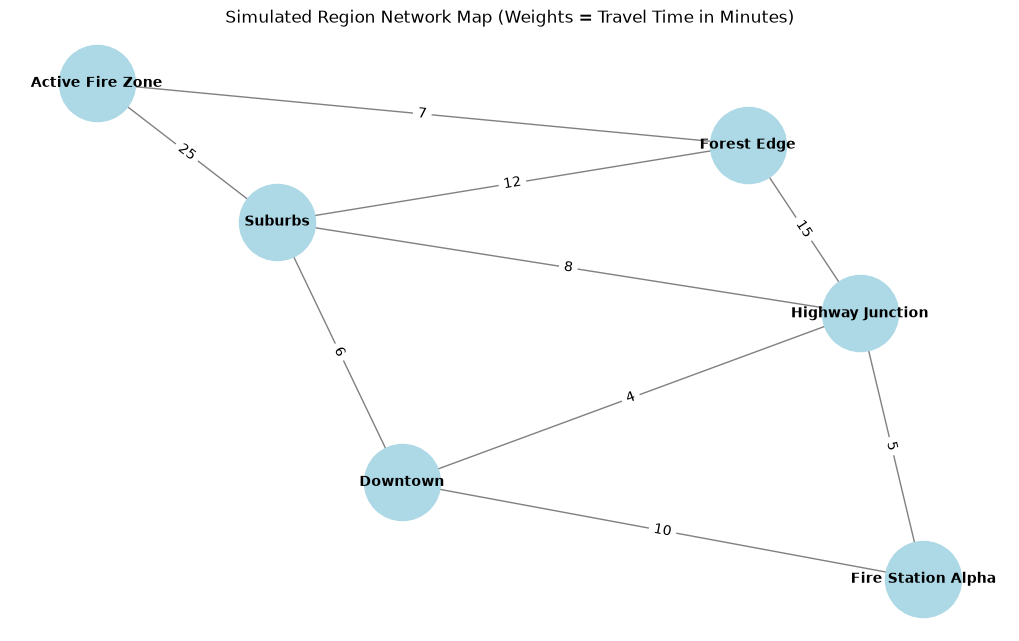

In [14]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Initialize an empty map (Graph)
city_map = nx.Graph()

# 2. Add edges (Roads) and their travel times (Weights in minutes)
# Format: (Location A, Location B, Travel Time)
roads = [
    ('Fire Station Alpha', 'Highway Junction', 5),
    ('Fire Station Alpha', 'Downtown', 10),
    ('Downtown', 'Highway Junction', 4),
    ('Highway Junction', 'Suburbs', 8),
    ('Downtown', 'Suburbs', 6),
    ('Suburbs', 'Forest Edge', 12),
    ('Highway Junction', 'Forest Edge', 15),
    ('Forest Edge', 'Active Fire Zone', 7),
    ('Suburbs', 'Active Fire Zone', 25) # A long, winding dirt road
]

# Unpack our roads into the graph
city_map.add_weighted_edges_from(roads)

# 3. Visualize the Map
plt.figure(figsize=(10, 6))
# Create a layout that spaces the nodes out nicely
pos = nx.spring_layout(city_map, seed=42) 

# Draw the nodes and labels
nx.draw(city_map, pos, with_labels=True, node_color='lightblue', 
        node_size=3000, font_size=10, font_weight='bold', edge_color='gray')

# Draw the travel times on the edges
edge_labels = nx.get_edge_attributes(city_map, 'weight')
nx.draw_networkx_edge_labels(city_map, pos, edge_labels=edge_labels)

plt.title("Simulated Region Network Map (Weights = Travel Time in Minutes)")
plt.show()

In [15]:
# 1. Define our starting point and emergency destination
origin = 'Fire Station Alpha'
destination = 'Active Fire Zone'

# 2. Calculate the fastest route using Dijkstra's Algorithm
# The 'weight' parameter tells it to look at the travel times, not just the number of stops
fastest_route = nx.shortest_path(city_map, source=origin, target=destination, weight='weight')

# 3. Calculate the total travel time for this specific route
total_time = nx.shortest_path_length(city_map, source=origin, target=destination, weight='weight')

# 4. Output the dispatch instructions
print("🚨 DISPATCH PROTOCOL INITIATED 🚨")
print("-" * 30)
print(f"Origin: {origin}")
print(f"Destination: {destination}")
print("-" * 30)
print(f"Optimal Route: {' ➔ '.join(fastest_route)}")
print(f"Estimated Travel Time: {total_time} minutes")

🚨 DISPATCH PROTOCOL INITIATED 🚨
------------------------------
Origin: Fire Station Alpha
Destination: Active Fire Zone
------------------------------
Optimal Route: Fire Station Alpha ➔ Highway Junction ➔ Forest Edge ➔ Active Fire Zone
Estimated Travel Time: 27 minutes


In [16]:
import torch.optim as optim

# 1. Define the Upgraded Network with adjustable parameters and Dropout
class TunedWildfirePredictor(nn.Module):
    def __init__(self, input_size, hidden1, hidden2, dropout_rate):
        super(TunedWildfirePredictor, self).__init__()
        
        self.layer1 = nn.Linear(input_size, hidden1)
        self.dropout1 = nn.Dropout(dropout_rate) # Adds regularization
        self.relu1 = nn.ReLU()
        
        self.layer2 = nn.Linear(hidden1, hidden2)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.relu2 = nn.ReLU()
        
        self.output_layer = nn.Linear(hidden2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu1(self.dropout1(self.layer1(x)))
        x = self.relu2(self.dropout2(self.layer2(x)))
        x = self.sigmoid(self.output_layer(x))
        return x

# 2. Define the configurations we want to test
configurations = [
    {'name': 'Baseline (Wider)', 'hidden1': 32, 'hidden2': 16, 'lr': 0.01, 'dropout': 0.0},
    {'name': 'Robust (Dropout)', 'hidden1': 32, 'hidden2': 16, 'lr': 0.01, 'dropout': 0.2},
    {'name': 'Deep & Slow', 'hidden1': 64, 'hidden2': 32, 'lr': 0.001, 'dropout': 0.3},
    {'name': 'Light & Fast', 'hidden1': 16, 'hidden2': 8, 'lr': 0.05, 'dropout': 0.1}
]

best_accuracy = 0
best_config_name = ""
input_dimensions = X_train_tensor.shape[1]
epochs = 150
criterion = nn.BCELoss()

print("🚀 Starting Hyperparameter Tuning...\n")

# 3. The Tuning Loop: Train and test each configuration
for config in configurations:
    print(f"Testing Config: {config['name']} (H1:{config['hidden1']}, H2:{config['hidden2']}, LR:{config['lr']}, Drop:{config['dropout']})")
    
    # Initialize model with this loop's settings
    test_model = TunedWildfirePredictor(
        input_dimensions, 
        config['hidden1'], 
        config['hidden2'], 
        config['dropout']
    ).to(device)
    
    optimizer = optim.Adam(test_model.parameters(), lr=config['lr'])
    
    # Train the model
    test_model.train()
    for epoch in range(epochs):
        predictions = test_model(X_train_tensor)
        loss = criterion(predictions, y_train_tensor)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # Evaluate the model
    test_model.eval()
    with torch.no_grad():
        test_predictions = test_model(X_test_tensor)
        rounded_predictions = test_predictions.round()
        correct_guesses = (rounded_predictions == y_test_tensor).sum().item()
        accuracy = (correct_guesses / y_test_tensor.size(0)) * 100
        
    print(f"➔ Final Loss: {loss.item():.4f} | Test Accuracy: {accuracy:.2f}%\n")
    
    # Track the winner
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_config_name = config['name']
        # You could save the best model weights here in a real production environment!

print("-" * 40)
print(f"🏆 WINNER: {best_config_name} with {best_accuracy:.2f}% Accuracy")
print("-" * 40)

🚀 Starting Hyperparameter Tuning...

Testing Config: Baseline (Wider) (H1:32, H2:16, LR:0.01, Drop:0.0)
➔ Final Loss: 0.0009 | Test Accuracy: 95.92%

Testing Config: Robust (Dropout) (H1:32, H2:16, LR:0.01, Drop:0.2)
➔ Final Loss: 0.0069 | Test Accuracy: 95.92%

Testing Config: Deep & Slow (H1:64, H2:32, LR:0.001, Drop:0.3)
➔ Final Loss: 0.0805 | Test Accuracy: 93.88%

Testing Config: Light & Fast (H1:16, H2:8, LR:0.05, Drop:0.1)
➔ Final Loss: 0.0032 | Test Accuracy: 95.92%

----------------------------------------
🏆 WINNER: Baseline (Wider) with 95.92% Accuracy
----------------------------------------


In [17]:
import torch

print("Saving production model...")

# 1. Instantiate the winning architecture
production_model = TunedWildfirePredictor(input_dimensions, hidden1=32, hidden2=16, dropout_rate=0.0).to(device)
optimizer = optim.Adam(production_model.parameters(), lr=0.01)
criterion = nn.BCELoss()

# 2. Train it quickly
production_model.train()
for epoch in range(150):
    predictions = production_model(X_train_tensor)
    loss = criterion(predictions, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# 3. Save the model weights to your project directory
torch.save(production_model.state_dict(), 'wildfire_production_model.pth')
print("✅ Success! 'wildfire_production_model.pth' has been saved to your project folder.")

Saving production model...
✅ Success! 'wildfire_production_model.pth' has been saved to your project folder.


In [18]:
import joblib

# Assuming your scaler variable is named 'scaler'
joblib.dump(scaler, 'wildfire_scaler.pkl')

['wildfire_scaler.pkl']